# Анализ реестра предпринимателей

## Сборка датасета

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# загрузка данных из Excel-файла
file_path = "Реестр.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Лист1",
    header=2,          # заголовки находятся в 3-й строке
    nrows=603520
)

print("Размер исходного датасета:", df.shape)
df

Размер исходного датасета: (603520, 23)


,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
0,1,""" МЕГАПОЛИС "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВ...",Юридическое лицо,Не является субъектом МСП,1027800523376,7801190028,41.2 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.10.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
1,2,""" СТАЛЬИНВЕСТСТРОЙ "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1037800033545,7801227976,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.08.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
2,3,""" СТРОЙТЕХНИКА - М "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1025204418293,5263039399,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,10.07.2022,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
3,4,"""БАЗИС"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1025204411682,5263025484,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,1.0
4,5,"""БЕЛАГ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Не является субъектом МСП,1037800039276,7801123215,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.07.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603515,603516,ЯЩУК ОЛЕГ АЛЕКСАНДРОВИЧ,Индивидуальный предприниматель,Не является субъектом МСП,317774600355312,771988802222,41.20 Строительство жилых и нежилых зданий,77 - г.Москва,NaN,NaN,...,10.07.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
603516,603517,ЯЩУК ТАТЬЯНА АНАТОЛЬЕВНА,Индивидуальный предприниматель,Не является субъектом МСП,315774600285615,772104692120,41.20 Строительство жилых и нежилых зданий,77 - г.Москва,NaN,NaN,...,10.08.2020,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
603517,603518,ЯЩУКОВСКИЙ НИКОЛАЙ ПЕТРОВИЧ,Индивидуальный предприниматель,Микропредприятие,324080000003782,700607364953,41.20 Строительство жилых и нежилых зданий,08 - Республика Калмыкия,Юстинский р-н,NaN,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
603518,603519,ЯЩУРИНСКАЯ НАТАЛЬЯ ПЕТРОВНА,Индивидуальный предприниматель,Не является субъектом МСП,318507400035652,370305350203,41.20 Строительство жилых и нежилых зданий,50 - Московская область,NaN,ГОРОД СЕРПУХОВ,...,10.08.2020,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN


In [ ]:
df.columns = [
    "index",
    "name",
    "subject_type",
    "category",
    "ogrn",
    "inn",
    "activity",
    "region",
    "district",
    "city",
    "settlement",
    "new_subject",
    "date_inclusion",
    "date_exclusion",
    "phone",
    "email",
    "www",
    "has_license",
    "has_contracts",
    "innovative_production",
    "partnership_program",
    "social_enterprise",
    "employees"
]

df = df.set_index("index")



In [ ]:
df.head()

,name,subject_type,category,ogrn,inn,activity,region,district,city,settlement,...,date_exclusion,phone,email,www,has_license,has_contracts,innovative_production,partnership_program,social_enterprise,employees
index,,,,,,,,,,,,,,,,,,,,,
1,""" МЕГАПОЛИС "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВ...",Юридическое лицо,Не является субъектом МСП,1027800523376,7801190028,41.2 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,NaN,...,10.10.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
2,""" СТАЛЬИНВЕСТСТРОЙ "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1037800033545,7801227976,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,NaN,...,10.08.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
3,""" СТРОЙТЕХНИКА - М "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1025204418293,5263039399,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,NaN,...,10.07.2022,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
4,"""БАЗИС"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1025204411682,5263025484,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,NaN,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,1.0
5,"""БЕЛАГ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Не является субъектом МСП,1037800039276,7801123215,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,NaN,...,10.07.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN


### Очистка датасета 

In [ ]:
# очистка от лишних пробелов

text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

In [ ]:
print("Размер датасета до очистки:", df.shape)

print("Количество полностью пустых строк:", df.isna().all(axis=1).sum())
df = df.dropna(how="all") # удаление полностью пустых строк

# удаление дубликатов
print("Количество дубликатов:", df.duplicated().sum())

df = df.drop_duplicates().copy()

print("Размер датасета после очистки:", df.shape)

Размер датасета до очистки: (603520, 22)
Количество полностью пустых строк: 0
Количество дубликатов: 0
Размер датасета после очистки: (603520, 22)


### Фильтрация датасета

In [ ]:
# фильтрация данных по условиям
condition_subject_type = df["subject_type"] == "Юридическое лицо"
condition_Category = df["category"].isin(["Малое предприятие", "Среднее предприятие"])
condition_activity = df["activity"] == "41.20 Строительство жилых и нежилых зданий"  

all_conditions = condition_subject_type & condition_Category & condition_activity


df_filtered = df[all_conditions]

### Cохранение подготовленного датасета


In [ ]:
# сохранение подготовленного датасета
df_filtered.to_csv(
    "reestr_prepared.csv",
    index=False,
    encoding="utf-8-sig"
)

## Финальный датасет

### Краткое описание столбцов

| Столбец | Значение |
|---|---|
| `name` | Наименование / ФИО |
| `subject_type` | Тип субъекта |
| `category` | Категория |
| `ogrn` | ОГРН |
| `inn` | ИНН |
| `activity` | Основной вид деятельности |
| `region` | Регион |
| `district` | Район |
| `city` | Город |
| `settlement` | Населенный пункт |
| `new_subject` | Вновь созданный |
| `date_inclusion` | Дата включения в реестр |
| `date_exclusion` | Дата исключения из реестра |
| `phone` | Телефон |
| `email` | E-mail |
| `www` | WWW |
| `has_license` | Наличие лицензий |
| `has_contracts` | Наличие заключенных договоров, контрактов |
| `innovative_production` | Производство инновационной, высокотехнологичной продукции |
| `partnership_program` | Участие в программах партнерства |
| `social_enterprise` | Является социальным предприятием |
| `employees` | Среднесписочная численность работников за предшествующий календарный год |

In [4]:
df = pd.read_csv(
    "reestr_prepared.csv",
    sep=",",
    encoding="utf-8-sig"
    )
df.head()

,name,subject_type,category,ogrn,inn,activity,region,district,city,settlement,...,date_exclusion,phone,email,www,has_license,has_contracts,innovative_production,partnership_program,social_enterprise,employees
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Юридическое лицо,Малое предприятие,1025004907080,5038038838,41.20 Строительство жилых и нежилых зданий,50 - Московская область,Пушкино г,NaN,NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,36.0
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Юридическое лицо,Среднее предприятие,1025007270551,5027006369,41.20 Строительство жилых и нежилых зданий,50 - Московская область,NaN,г Дзержинский,NaN,...,NaN,NaN,NaN,NaN,True,False,False,False,False,201.0
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Юридическое лицо,Малое предприятие,1021400692048,1414006922,41.20 Строительство жилых и нежилых зданий,77 - г.Москва,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,True,False,False,False,False,35.0
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Юридическое лицо,Малое предприятие,1043301806415,3327332190,41.20 Строительство жилых и нежилых зданий,33 - Владимирская область,NaN,г Владимир,NaN,...,NaN,NaN,NaN,NaN,True,False,False,False,False,52.0
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Юридическое лицо,Малое предприятие,1027807999988,7816061297,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,True,False,False,False,False,21.0


### Преобразование типов данных

In [ ]:
df.dtypes

name                      object
subject_type              object
category                  object
ogrn                       int64
inn                        int64
activity                  object
region                    object
district                  object
city                      object
settlement                object
new_subject                 bool
date_inclusion            object
date_exclusion           float64
phone                     object
email                     object
www                       object
has_license                 bool
has_contracts               bool
innovative_production       bool
partnership_program         bool
social_enterprise           bool
employees                float64
dtype: object

In [ ]:
# приведение идентификаторов ОГРН и ИНН и наименования организаций к строковому типу данных
df["ogrn"] = df["ogrn"].astype("string")
df["inn"] = df["inn"].astype("string")
df["name"] = df["name"].astype("string")

# преобразование дат
df["date_inclusion"] = pd.to_datetime(
    df["date_inclusion"],
    format="%d.%m.%Y",
    errors="coerce"
)

df["date_exclusion"] = pd.to_datetime(
    df["date_exclusion"],
    format="%d.%m.%Y",
    errors="coerce"
)


# преобразование числовых значений в столбце "employees" к типу данных Int64
df["employees"] = df["employees"].astype("Int64")


# приведение бинарных признаков
binary_columns = [
    "new_subject",
    "has_license",
    "has_contracts",
    "innovative_production",
    "partnership_program",
    "social_enterprise"
]

for col in binary_columns:
    df[col] = (
        df[col]
        .replace({
            "Да": True,
            "Нет": False
        })
        .astype("boolean")
    )


# приведение категориальных признаков к типу category
category_columns = [
    "subject_type",
    "activity",
    "category",
    "region",
    "district",
    "city",
    "settlement"
]

for col in category_columns:
    df[col] = df[col].astype("category")

In [ ]:
df.dtypes

name                     string[python]
subject_type                   category
category                       category
ogrn                     string[python]
inn                      string[python]
activity                       category
region                         category
district                       category
city                           category
settlement                     category
new_subject                     boolean
date_inclusion           datetime64[ns]
date_exclusion           datetime64[ns]
phone                            object
email                            object
www                              object
has_license                     boolean
has_contracts                   boolean
innovative_production           boolean
partnership_program             boolean
social_enterprise               boolean
employees                         Int64
dtype: object

## Парсинг данных. Подсчёт метрики EBITDA

In [5]:
import requests
import json

session = requests.Session()
session.headers.update({
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/150.0.0.0 Safari/537.36"
    ),
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7",
    "Referer": "https://bo.nalog.gov.ru/"
})

In [6]:
# функция для получения финансовых данных по ИНН
def get_financial_data(inn, session):
    # поиск организации по ИНН
    res = session.get(
        "https://bo.nalog.gov.ru/advanced-search/organizations/search",
        params={
            "query": inn,
            "page": 0
        }
    )

    # проверка успешности запроса
    if res.status_code != 200:
        print(f"Ошибка при поиске организации с ИНН {inn}: {res.status_code}")
        return None

    search_result = res.json()

    # если организация не найдена, возвращаем None
    if not search_result["content"]:
        print(f"Организация с ИНН {inn} не найдена.")
        return None

    org_id = search_result["content"][0]["id"]

    bfo_res = session.get(
        f"https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo"
    )

    # проверка успешности запроса
    if bfo_res.status_code != 200:
        print(f"Ошибка при получении финансовых данных для ИНН {inn}: {bfo_res.status_code}")
        return None

    bfo = bfo_res.json()

    result = []
    
    # перебираем отчётность по годам
    for report in bfo:
        
        year = int(report["period"])
        
        try:
            financial = (
                report["typeCorrections"][0]
                ["correction"]["financialResult"]
            )
        except (KeyError, IndexError):
            continue
        
        result.append({
            "inn": inn,
            "year": year,
            "net_profit": financial.get("current2400"),
            "interest": financial.get("current2330"),
            "tax": financial.get("current2410")
        })
    
    return result


In [8]:
all_financial_data = []

inns = df["inn"]

for i, inn in enumerate(inns):
    
    try:
        data = get_financial_data(inn, session)
        all_financial_data.extend(data)
        
        print(
            f"{i + 1}/{len(inns)} — {inn} — получено {len(data)} лет", end="\r"
        )
        
    except Exception as e:
        print(
            f"{i + 1}/{len(inns)} — {inn} — ошибка: {e}"
        )

Организация с ИНН 5009106346 не найдена.
10/8927 — 5009106346 — ошибка: 'NoneType' object is not iterable


KeyboardInterrupt: 

In [ ]:
# создание DataFrame с финансовыми данными
financial_df = pd.DataFrame(all_financial_data)

# расчет показателя EBITDA (без амортизации)
financial_df["ebitda"] = (
    financial_df["net_profit"]+financial_df["interest"]+financial_df["tax"]
)

# сохранение финансовых данных в CSV-файл
financial_df.to_csv(
    "financial_data.csv",
    index=False,
    encoding="utf-8-sig"
)

financial_df.head(8)
# financial_df.dtypes

,inn,year,net_profit,interest,tax,ebitda
0,5038038838,2023,-20913.0,3334.0,-248.0,-17827.0
1,5038038838,2021,3080.0,5601.0,-320.0,8361.0
2,5038038838,2024,-20129.0,1521.0,-191.0,-18799.0
3,5038038838,2022,19518.0,141.0,-336.0,19323.0
4,5038038838,2025,-520.0,11869.0,-63.0,11286.0
5,5027006369,2022,31442.0,2791.0,-8568.0,25665.0
6,5027006369,2025,704973.0,324.0,-48275.0,657022.0
7,5027006369,2024,28998.0,705.0,-8184.0,21519.0


In [ ]:
financial_df = pd.read_csv(
    "financial_data.csv",  
    index_col=False,
    encoding="utf-8-sig"
)
financial_df.head()

,inn,year,net_profit,interest,tax,ebitda
0,5038038838,2023,-20913.0,3334.0,-248.0,-17827.0
1,5038038838,2021,3080.0,5601.0,-320.0,8361.0
2,5038038838,2024,-20129.0,1521.0,-191.0,-18799.0
3,5038038838,2022,19518.0,141.0,-336.0,19323.0
4,5038038838,2025,-520.0,11869.0,-63.0,11286.0


In [ ]:
# расчет суммарного показателя EBITDA по годам
ebitda_by_year = (
    financial_df
    .groupby("year")["ebitda"]
    .sum()
    .reset_index()
)
ebitda_by_year

,year,ebitda
0,2021,27658585.0
1,2022,48664793.0
2,2023,60348425.0
3,2024,78299740.0
4,2025,71679564.0


## Построение графиков распределения процента роста чистой прибыли компаний относительно N-летней давности

In [ ]:
# ввод числа лет для анализа
while True:
    user_input = input("Введите число лет для анализа (не больше 4): ")
    
    try:
        N = int(user_input)  
    except ValueError:
        print("Ошибка: введите целое число.")
        continue 

    if N > 4:
        print("Ошибка: число лет не должно превышать 4.")
    elif N < 1:
        print("Ошибка: число лет должно быть положительным.")
    elif N == 1:
        print(f"Выбранный период анализа: {N} год")
        break
    else:
        print(f"Выбранный период анализа: {N} года")
        break


Выбранный период анализа: 3 года


### График 1 (Распеределение по каждому проценту + ограничение по оси X)

In [ ]:
# расчет процентного изменения чистой прибыли по годам для каждой организации
df_growth = (
    financial_df[['inn', 'year', 'net_profit']]
    .sort_values(by=['inn', 'year'])
    .reset_index(drop=True)
    .copy()
)



# расчет процентного изменения чистой прибыли
df_growth['net_profit_growth'] = (
    df_growth
    .groupby('inn')['net_profit']
    # .sort_values(by='year', ascending=True)
    .pct_change(periods=N) * 100
)


# фильтрация данных по году 2025 
df_growth = (
    df_growth[(df_growth['year'] == 2025)]
    .sort_values(by="net_profit_growth", ascending=True)
    .reset_index(drop=True)
)
df_growth
# округление значений процентного изменения чистой прибыли до 2-х знаков после запятой
df_growth['net_profit_growth'] = (
    df_growth['net_profit_growth']
    .round(0)
    # .astype("int")
)   

# # Удаляем строки с inf и бесконечными значениями
df_growth = df_growth[df_growth['net_profit_growth'] != float('inf')]
df_growth = df_growth[df_growth['net_profit_growth'] != float('-inf')]

# # Удаляем слишком большие значения (например, > |1000%|)
# df_growth = df_growth[df_growth['net_profit_growth'].abs() <= 200]

growth_count = (
    df_growth['net_profit_growth']
    .value_counts()
    .sort_index(ascending=False)
)

df_growth
# growth_count



C:\Users\ПК\AppData\Local\Temp\ipykernel_11836\1982475686.py:16: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change(periods=N) * 100


,inn,year,net_profit,net_profit_growth
18,9715264199,2025,-693154.0,-11552667.0
19,7816595980,2025,-127097.0,-4236667.0
20,2723093561,2025,-37811.0,-1260467.0
21,7811004802,2025,-1490901.0,-1050030.0
22,3849067963,2025,63726.0,-455286.0
...,...,...,...,...
7160,9709067851,2025,452.0,NaN
7161,9715224421,2025,46532.0,NaN
7162,9715228345,2025,NaN,NaN
7163,9722031036,2025,4337.0,NaN


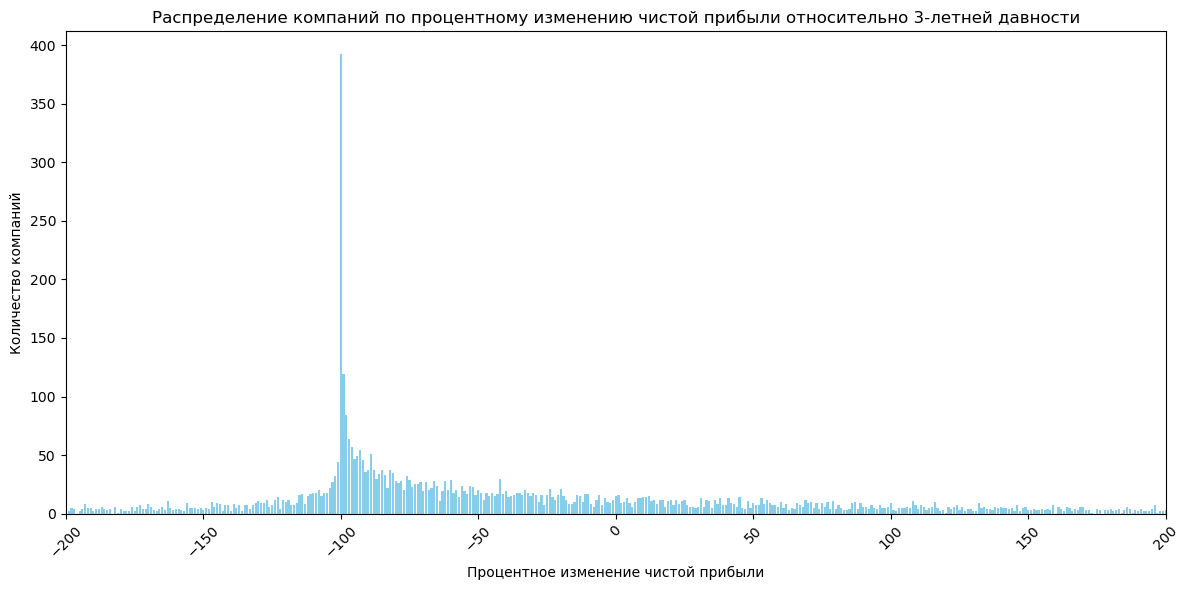

In [ ]:
# график распределения компаний по процентному изменению чистой прибыли
plt.figure(figsize=(12, 6))
plt.bar(
    growth_count.index,
    growth_count.values,
    color='skyblue',
    # edgecolor='black'
)
# ограничим ось X для лучшей визуализации
plt.xlim(-200, 200)
plt.xlabel('Процентное изменение чистой прибыли')
plt.ylabel('Количество компаний')
plt.title(f'Распределение компаний по процентному изменению чистой прибыли относительно {N}-летней давности')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### График 2 (по интервалам) 

In [ ]:
# создание интервалов для группировки процентного изменения чистой прибыли
bins = [-np.inf, -100, -50, -20, -10, 0, 10, 20, 50, 100, np.inf]
# названия интервалов
labels = ['<-100%', '-100% to -50%', '-50% to -20%', '-20% to -10%', '-10% to 0%', '0% to 10%', '10% to 20%', '20% to 50%', '50% to 100%', '>100%']

# создание нового столбца с интервалами процентного изменения чистой прибыли
df_growth['growth_interval'] = pd.cut(
    df_growth['net_profit_growth'],
    bins=bins,
    labels=labels
)

growth_interval_count = (
    df_growth['growth_interval']
    .value_counts()
    .sort_index(ascending=True)   
)

growth_interval_count

growth_interval
<-100%           2095
-100% to -50%    1614
-50% to -20%      496
-20% to -10%      128
-10% to 0%        108
0% to 10%         113
10% to 20%        113
20% to 50%        258
50% to 100%       344
>100%            1788
Name: count, dtype: int64

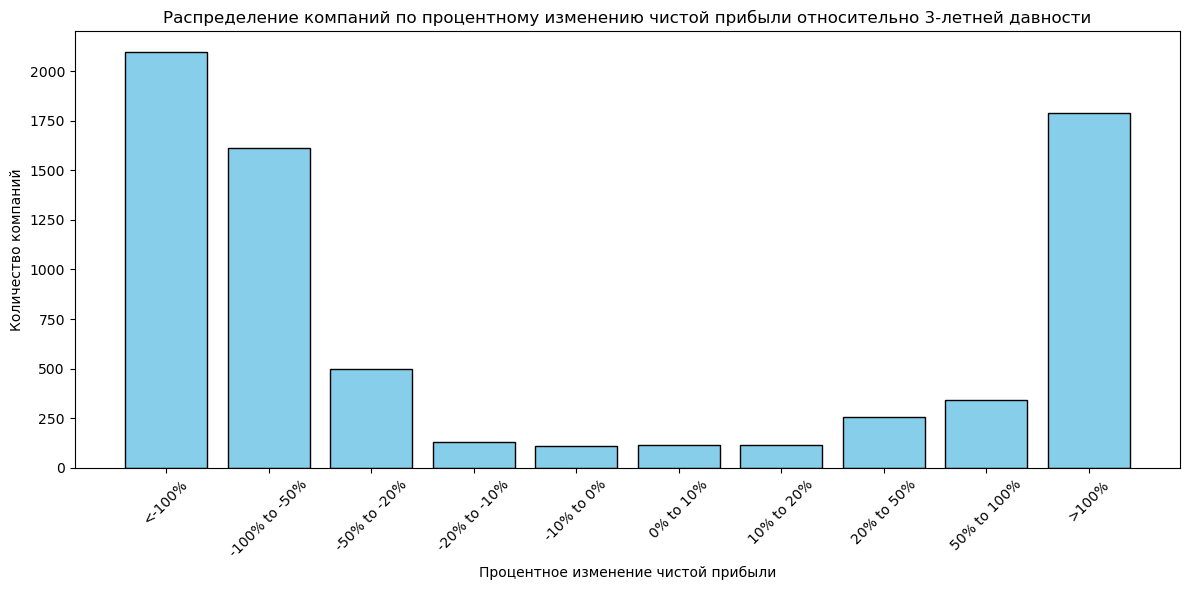

In [ ]:
# график распределения компаний по процентному изменению чистой прибыли с интервалами
plt.figure(figsize=(12, 6))
plt.bar(
    growth_interval_count.index,
    growth_interval_count.values,
    color='skyblue',
    edgecolor='black'
)
# ограничим ось X для лучшей визуализации
# plt.xlim(-200, 200)
plt.xlabel('Процентное изменение чистой прибыли')
plt.ylabel('Количество компаний')
plt.title(f'Распределение компаний по процентному изменению чистой прибыли относительно {N}-летней давности')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Вывод (для 3-ёх лет)

Из полученного графика можем видеть, что изменение чистой прибыли у компаний за трёхлетний период сильно различается. Значительная часть компаний столкнулась с существенным снижением прибыли, при этом у сопоставимого числа компаний, наоборот, наблюдался значительный рост. При этом большое количество экстремальных значений может быть связано с низкой или отрицательной прибылью за некоторые годы. В целом можно сделать вывод о высоком разнообразии финансовых результатов компаний за рассматриваемый период.

## Топ 500 компаний по выручке

In [9]:
# функция для парсинга выручки для каждой компании по ИНН
def get_revenue_data(inn, session):
    # поиск организации по ИНН
    res = session.get(
        "https://bo.nalog.gov.ru/advanced-search/organizations/search",
        params={
            "query": inn,
            "page": 0
        }
    )

    # проверка успешности запроса
    if res.status_code != 200:
        print(f"Ошибка при поиске организации с ИНН {inn}: {res.status_code}")
        return None

    search_result = res.json()

    # если организация не найдена, возвращаем None
    if not search_result["content"]:
        print(f"Организация с ИНН {inn} не найдена.")
        return None

    org_id = search_result["content"][0]["id"]

    bfo_res = session.get(
        f"https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo"
    )

    # проверка успешности запроса
    if bfo_res.status_code != 200:
        print(f"Ошибка при получении финансовых данных для ИНН {inn}: {bfo_res.status_code}")
        return None

    bfo = bfo_res.json()

    result = []
    
    # перебираем отчётность по годам
    for report in bfo:
        
        year = int(report["period"])
        
        try:
            financial = (
                report["typeCorrections"][0]
                ["correction"]["financialResult"]
            )
        except (KeyError, IndexError):
            continue
        
        result.append({
            "inn": inn,
            "year": year,
            "revenue": financial.get("current2110")
        })
    
    return result

In [10]:
# создание DataFrame с выручкой по компаниям
all_revenue_data = []
inns = df["inn"]
# применим функцию get_revenue_data для каждой компании по ИНН
for i, inn in enumerate(inns):
    try:
        data = get_revenue_data(inn, session)
        all_revenue_data.extend(data)
        
        print(
            f"{i + 1}/{len(inns)} — {inn} — получено {len(data)} лет",
            end="\r"
        )
        
    except Exception as e:
        print(
            f"{i + 1}/{len(inns)} — {inn} — ошибка: {e}"
        )



Организация с ИНН 5009106346 не найдена.
10/8927 — 5009106346 — ошибка: 'NoneType' object is not iterable


KeyboardInterrupt: 

In [11]:
df_revenue = pd.DataFrame(all_revenue_data)

## сохранение данных по выручке в CSV-файл
df_revenue.to_csv(
    "revenue_data.csv",
    index=False,
    encoding="utf-8-sig"
)

df_revenue


,inn,year,revenue
0,5038038838,2023,108966.0
1,5038038838,2021,184044.0
2,5038038838,2024,112540.0
3,5038038838,2022,118633.0
4,5038038838,2025,140064.0
...,...,...,...
236,3906034170,2021,13005.0
237,3906034170,2022,14222.0
238,7714406538,2023,249511.0
239,7714406538,2021,366471.0


In [ ]:
# прочитываем данные по выручке из CSV-файла
df_revenue = pd.read_csv(  
    "revenue_data.csv",   
    index_col=False,
    encoding="utf-8-sig"
)

# фильтрация данных по году 2025
df_revenue = df_revenue[df_revenue['year'] == 2025]
# удаление стобца "year", так как он больше не нужен
df_revenue = df_revenue.drop(columns=['year'])

# создание DataFrame с именами компаний
name_df = df[['inn', 'name']].drop_duplicates()
# объединение данных по выручке с данными по именам компаний
df_revenue = pd.merge(df_revenue, name_df, on='inn', how='left')


# создание DataFrame с городами компаний
city_df = df[['inn', 'city']].drop_duplicates()
# объединение данных по выручке с данными по городам
df_revenue = pd.merge(df_revenue, city_df, on='inn', how='left')
# удаление первых двух символов в столбце city
df_revenue['city'] = df_revenue['city'].str[2:]

# удаляем с пустыми значениями города
df_revenue = df_revenue.dropna(subset=['city'])

# сортировка по выручке и выбор топ-500 компаний
df_revenue_top500 = (
    df_revenue
    .sort_values(by="revenue", ascending=False)
    .reset_index(drop=True)
    .head(500)
)



df_revenue_top500

,inn,revenue,name,city
0,5401304044,18261572.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОМ...",Новосибирск
1,5257145631,12406715.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СПЕЦ...",Нижний Новгород
2,4004021545,11677648.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ОРГ-...",Кондрово
3,7723906368,9768765.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВИК""",Домодедово
4,1655476201,8938370.0,ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ СТРОИ...,Казань
...,...,...,...,...
495,7326046300,836753.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТИМУЛ""",Самара
496,2204054375,833957.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МАТЕ...",Новосибирск
497,5404523005,831391.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ИНВЕ...",Новосибирск
498,5503251088,829970.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОФ...",Омск


In [ ]:
from geopy.geocoders import Nominatim
import time
import geopandas as gpd
import contextily as ctx
import plotly.express as px

In [ ]:
# соотнесёние городов с координатами
geolocator = Nominatim(
    user_agent="MyCityGeocoderApp/1.0 (dima2004201257@gmail.com)",
    timeout=15,
    scheme='https')

cities = df_revenue_top500['city'].dropna().unique()


cities_coordinates = []

for city in cities:
    try:
        location = geolocator.geocode(city)
        if location:
            cities_coordinates.append({
                "city": city,
                "latitude": location.latitude,
                "longitude": location.longitude
            })
            # счётчик для отслеживания прогресса
            print(f"Обработано {len(cities_coordinates)}/{len(cities)} городов\t\t\tКоординаты для города {city}: {location.latitude}, {location.longitude}", end="\r")
        else:
            cities_coordinates.append({
                "city": city,
                "latitude": None,
                "longitude": None
            })
    except Exception as e:
        print(f"Ошибка при получении координат для города {city}: {e}")
        cities_coordinates[city] = (None, None)
    
    time.sleep(2)  # задержка между запросами, чтобы избежать блокировки



In [ ]:
# создадим DataFrame с координатами городов
coordinates_df = pd.DataFrame(cities_coordinates)


# объединение компаний с координатами городов
top500_map = df_revenue_top500.merge(
    coordinates_df,
    on="city",
    how="inner"
)

# интерактивная карта
fig = px.scatter_map(
    top500_map,
    lat="latitude",
    lon="longitude",
    size="revenue",
    color="revenue",
    hover_name="name",
    hover_data={
        "city": True,
        "revenue": ":,.0f",
        "latitude": False,
        "longitude": False
    },
    color_continuous_scale="Viridis",
    zoom=3,
    height=700,
    title="Топ-500 компаний по выручке"
)

fig.update_layout(
    map_style="open-street-map",
    margin={"r": 0, "t": 40, "l": 0, "b": 0},

    coloraxis_colorbar=dict(
        title="Выручка, млн. руб.",
    )
)

fig.show()


,inn,revenue,name,city,latitude,longitude
0,5401304044,18261572.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОМ...",Новосибирск,55.028831,82.922689
1,5257145631,12406715.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СПЕЦ...",Нижний Новгород,56.326482,44.005139
2,4004021545,11677648.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ОРГ-...",Кондрово,54.806920,35.930121
3,7723906368,9768765.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВИК""",Домодедово,55.408712,37.909431
4,1655476201,8938370.0,ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ СТРОИ...,Казань,55.794649,49.111502
...,...,...,...,...,...,...
495,7326046300,836753.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТИМУЛ""",Самара,53.195625,50.101493
496,2204054375,833957.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МАТЕ...",Новосибирск,55.028831,82.922689
497,5404523005,831391.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ИНВЕ...",Новосибирск,55.028831,82.922689
498,5503251088,829970.0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОФ...",Омск,54.991375,73.371529


### Скриншот полученной карты

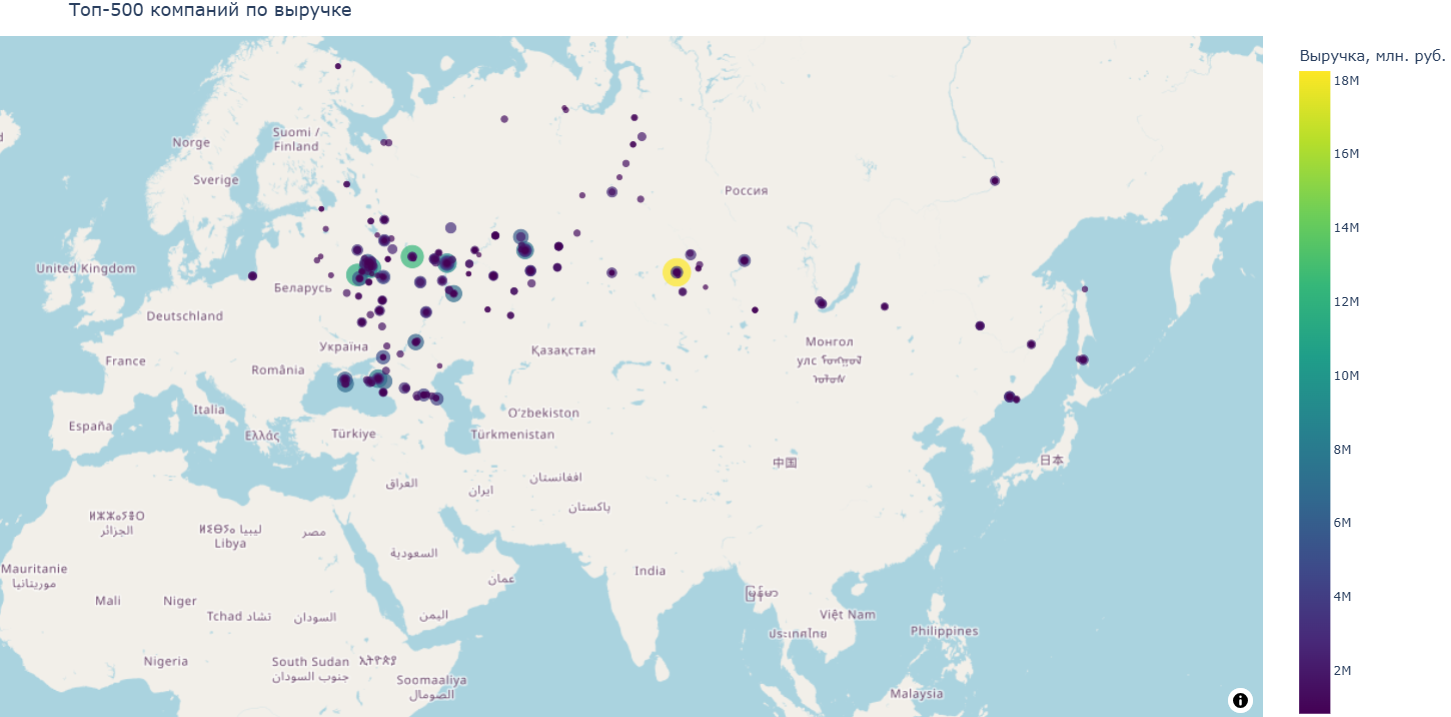